# Part 3: Attention Misalignment (GradCAM)

GradCAM-based spatial attribution of where **SigLIP 2 So400m** (same model used in the adapter/probe) attends when scoring an image-text pair. 

Three experiments:
1. **Correct vs. contradictory prompt**: single isolated object; does GradCAM change when the prompt contradicts the visible state?
2. **Binding in a two-object scene**: bowl + cup; does the model attend to the right object for each prompt?
3. **Spatial relation failure**: three-object left/centre/right scene; does attention localise to the correct position?

Expected from Part 1: experiments 2 and 3 show scattered/wrong attention, which is the visual signature of BoW behaviour.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from PIL import Image, ImageDraw
from transformers import AutoProcessor, AutoModel

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

# Must use attn_implementation='eager' for hooks to intercept layer tensors
MODEL_ID = 'google/siglip2-so400m-patch16-384'
proc = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID, attn_implementation='eager').to(device)
model.eval()
print('SigLIP 2 So400m loaded')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 8916.49it/s]


SigLIP 2 So400m loaded


## 2. GradCAM for ViT

For a Vision Transformer the spatial 'feature map' is the patch token sequence `[N, D]` from the last encoder layer. GradCAM:

1. **Forward hook** captures patch activations `A ∈ ℝ^{N×D}` from `encoder.layers[-1]`.
2. Compute similarity score `s = logits_per_image[0,0]` (**no** `torch.no_grad()`).
3. **Backward hook** captures gradients `G = ∂s/∂A ∈ ℝ^{N×D}`.
4. Channel weights: `α_d = (1/N) Σ_n G[n,d]` (global-average-pool over patch positions)
5. CAM: `cam[n] = ReLU(Σ_d α_d · A[n,d])` (importance per patch → reshape 24×24 → upsample)

For So400m with 384 px input and 16 px patches: grid = **24×24 = 576 tokens**.

In [ ]:
class SigLIPGradCAM:
    GRID = 24  # 384px / 16px patch = 24 patches per side

    def __init__(self, model, proc):
        self.model = model
        self.proc = proc
        self._acts = None
        self._grads = None
        last = model.vision_model.encoder.layers[-1]
        last.register_forward_hook(self._fwd_hook)
        last.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        # SiglipEncoderLayer returns tuple (hidden_states, ...) or just hidden_states
        self._acts = out[0] if isinstance(out, tuple) else out

    def _bwd_hook(self, module, grad_in, grad_out):
        self._grads = grad_out[0].detach()

    def compute(self, image: Image.Image, text: str):
        self.model.zero_grad()
        inputs = self.proc(
            images=[image], text=[text],
            return_tensors='pt', padding='max_length', truncation=True
        ).to(device)
        out = self.model(**inputs)           # gradients must flow — no no_grad
        score = out.logits_per_image[0, 0]
        score.backward()

        acts = self._acts.detach().squeeze(0)   # [N, D]
        grads = self._grads.squeeze(0)            # [N, D]

        # Global-average-pool gradients over patch positions → per-channel weight
        alpha = grads.mean(dim=0)                 # [D]
        cam = (alpha * acts).sum(dim=-1)        # [N]
        cam = cam[:self.GRID**2].reshape(self.GRID, self.GRID).cpu().numpy()
        cam = np.maximum(cam, 0)                # ReLU
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def overlay(self, image: Image.Image, cam, alpha: float = 0.5):
        W, H = image.size
        cam_up = np.array(
            Image.fromarray((cam * 255).astype('uint8')).resize((W, H), Image.BICUBIC)
        ) / 255.0
        coloured = mpl_cm.jet(cam_up)[..., :3]
        orig = np.array(image) / 255.0
        return ((1 - alpha) * orig + alpha * coloured).clip(0, 1)


gradcam = SigLIPGradCAM(model, proc)
print('GradCAM ready')

GradCAM ready


## 3. Load AI2-THOR crops

Single-object crops from `sim_crops_all.pkl` for Exp 1.
Multi-object scenes from `compositionality_scenes.pkl` for Exp 2 (binding) and Exp 3 (spatial).

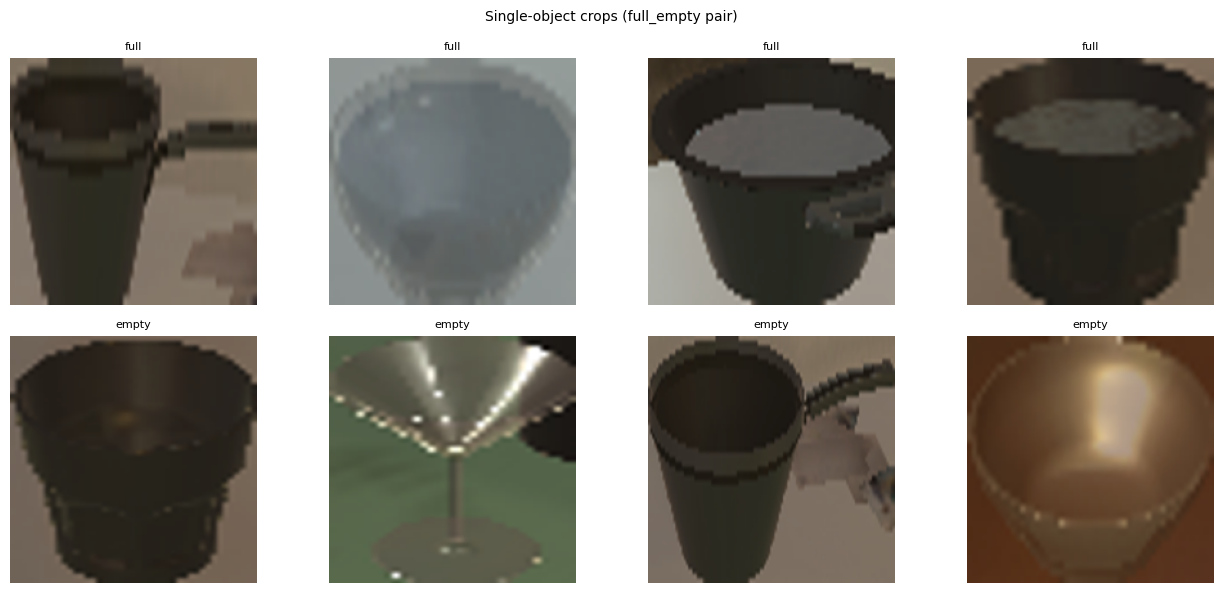

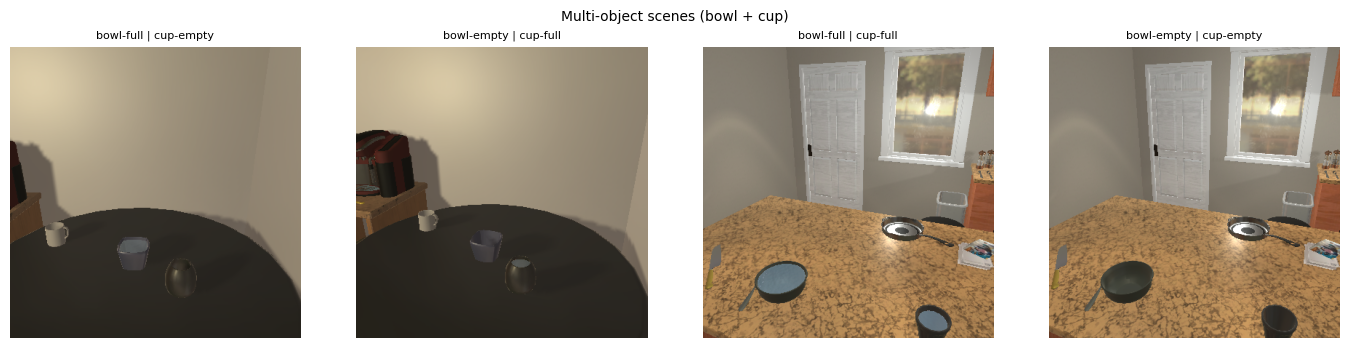

In [ ]:
import pickle, random
from pathlib import Path
from collections import defaultdict

random.seed(42)
DATA = Path('../data')
TILE = 192

with open(DATA / 'sim_crops_all.pkl', 'rb') as f:
    all_crops = pickle.load(f)

fe_empty = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 0]
fe_full = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 1]

with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp_scenes = pickle.load(f)

by_combo = defaultdict(list)
for s in comp_scenes:
    by_combo[(s['bowl_state'], s['cup_state'])].append(s)

def tile(s): return s['image'].resize((TILE, TILE), Image.BICUBIC)

# Preview
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for i, s in enumerate(random.sample(fe_full, 4)):
    axes[0, i].imshow(tile(s)); axes[0, i].set_title('full', fontsize=8); axes[0, i].axis('off')
for i, s in enumerate(random.sample(fe_empty, 4)):
    axes[1, i].imshow(tile(s)); axes[1, i].set_title('empty', fontsize=8); axes[1, i].axis('off')
axes[0, 0].set_ylabel('full'); axes[1, 0].set_ylabel('empty')
fig.suptitle('Single-object crops (full_empty pair)', fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (b, c) in zip(axes, [('full','empty'),('empty','full'),('full','full'),('empty','empty')]):
    ax.imshow(by_combo[(b,c)][0]['image'])
    ax.set_title(f'bowl-{b} | cup-{c}', fontsize=8); ax.axis('off')
fig.suptitle('Multi-object scenes (bowl + cup)', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Experiments

### Exp 1: Correct vs. contradictory (single object, real crops)
Full and empty crops from AI2-THOR. Does GradCAM focus on the liquid region for full crops? Does a contradictory prompt (calling a full container empty) produce a different or similar map?

### Exp 2: Binding in a two-object scene (real compositionality scenes)
Bowl + cup both visible in a real kitchen frame. Bowl-full|cup-empty scene. Correct prompts should activate the right object; wrong-binding prompts expected to scatter or activate the wrong object.

### Exp 3: Spatial grounding (real scenes, known bbox positions)
Use a scene where bowl and cup are on clearly different horizontal sides (verified from stored bboxes). Test whether `"the object on the left"` and `"the object on the right"` correctly localise. Contradictory position prompt (correct colour, wrong side) reveals whether the model uses position words at all.

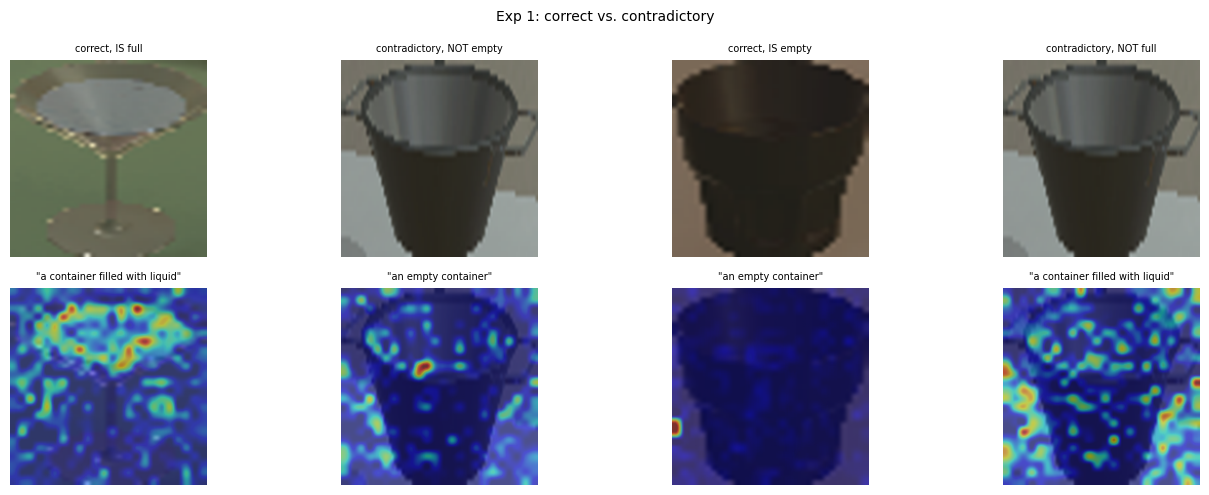

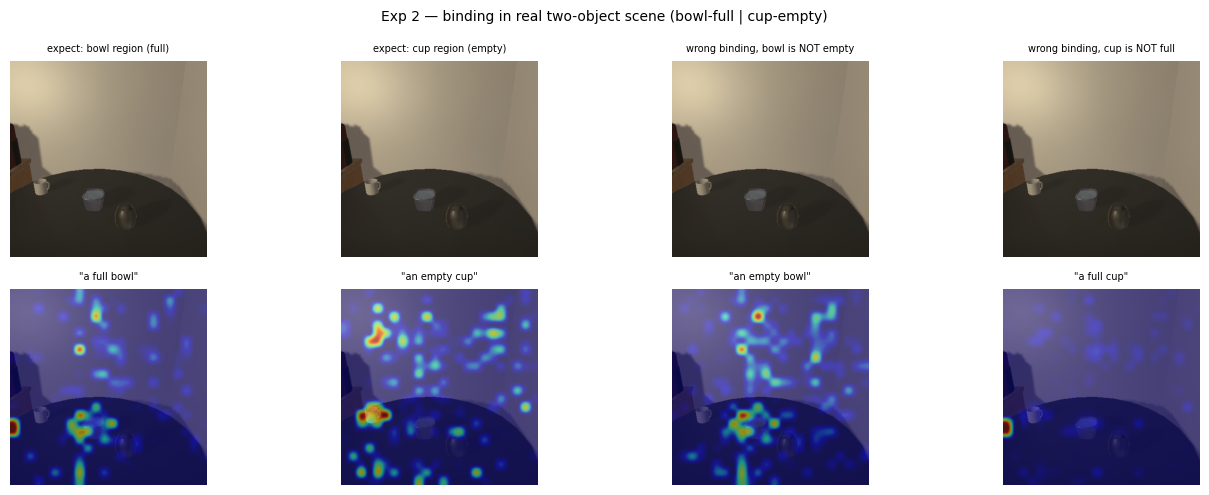

Bowl is on the left (cx=169),  Cup is on the right (cx=234)
Prompt                  bowl-side   cup-side   dominant
-------------------------------------------------------
a full bowl                0.0593     0.0221  bowl-side
an empty cup               0.0898     0.0430  bowl-side
an empty bowl              0.0761     0.0494  bowl-side
a full cup                 0.0200     0.0058  bowl-side


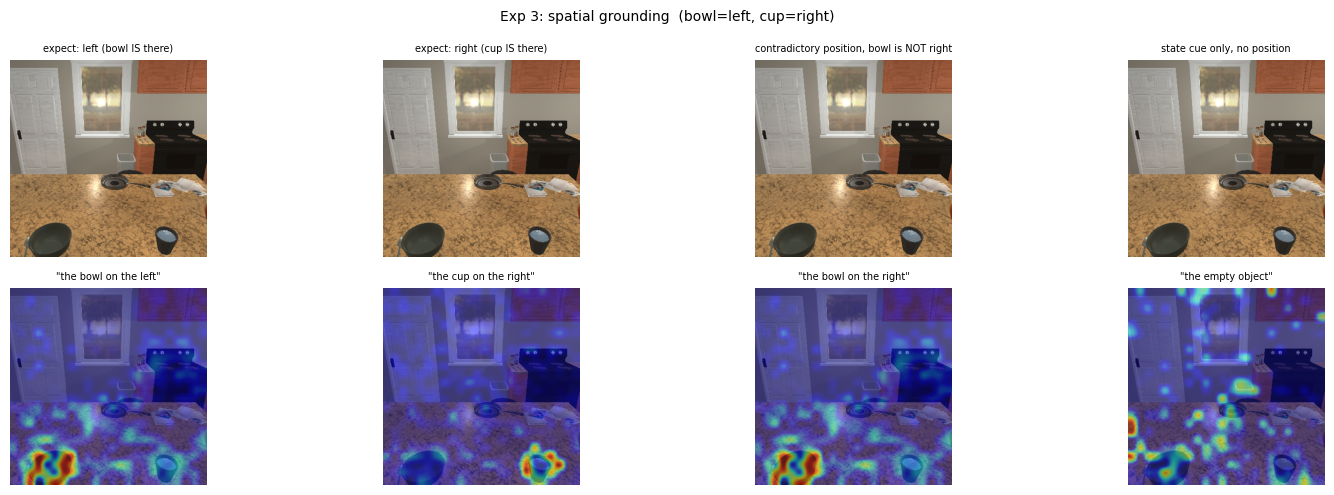


Prompt                                     left   right     peak
---------------------------------------------------------------
the bowl on the left                     0.1067  0.0887     left
the cup on the right                     0.0609  0.0751    right
the bowl on the right                    0.1104  0.0940     left
the empty object                         0.0983  0.0641     left


In [4]:
# Experiment 1: correct vs contradictory
cases_1 = [
    (tile(random.choice(fe_full)),  'a container filled with liquid', 'correct, IS full'),
    (tile(random.choice(fe_full)),  'an empty container', 'contradictory, NOT empty'),
    (tile(random.choice(fe_empty)), 'an empty container', 'correct, IS empty'),
    (tile(random.choice(fe_empty)), 'a container filled with liquid', 'contradictory, NOT full'),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for col, (img, prompt, title) in enumerate(cases_1):
    cam = gradcam.compute(img, prompt)
    axes[0, col].imshow(img)                      
    axes[0, col].set_title(title, fontsize=7)
    axes[1, col].imshow(gradcam.overlay(img, cam))
    axes[1, col].set_title(f'"{prompt}"', fontsize=7)
    for r in range(2): 
        axes[r, col].axis('off')
axes[0, 0].set_ylabel('image', fontsize=8)
axes[1, 0].set_ylabel('GradCAM', fontsize=8)
fig.suptitle('Exp 1: correct vs. contradictory', fontsize=10)
plt.tight_layout()
plt.show()


# Experiment 2: binding in real two-object scene
scene2 = by_combo[('full', 'empty')][0] # bowl full, cup empty
img2 = scene2['image']

cases_2 = [
    ('a full bowl',   'expect: bowl region (full)'),
    ('an empty cup',  'expect: cup region (empty)'),
    ('an empty bowl', 'wrong binding, bowl is NOT empty'),
    ('a full cup',    'wrong binding, cup is NOT full'),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for col, (prompt, label) in enumerate(cases_2):
    cam = gradcam.compute(img2, prompt)
    axes[0, col].imshow(img2)               
    axes[0, col].set_title(label, fontsize=7)
    axes[1, col].imshow(gradcam.overlay(img2, cam))
    axes[1, col].set_title(f'"{prompt}"', fontsize=7)
    for r in range(2):
        axes[r, col].axis('off')
axes[0, 0].set_ylabel('image', fontsize=8); axes[1, 0].set_ylabel('GradCAM', fontsize=8)
fig.suptitle('Exp 2 — binding in real two-object scene (bowl-full | cup-empty)', fontsize=10)
plt.tight_layout()
plt.show()

# Quantify: mean GradCAM in bowl-side vs cup-side (from stored bboxes)
b_cx = (scene2['bowl_bbox'][0] + scene2['bowl_bbox'][2]) / 2
c_cx = (scene2['cup_bbox'][0]  + scene2['cup_bbox'][2])  / 2
bowl_left = b_cx < c_cx
print(f'Bowl is on the {"left" if bowl_left else "right"} (cx={b_cx:.0f}),  '
      f'Cup is on the {"right" if bowl_left else "left"} (cx={c_cx:.0f})')
print(f'{"Prompt":<22} {"bowl-side":>10} {"cup-side":>10} {"dominant":>10}')
print('-' * 55)
for prompt, _ in cases_2:
    cam = gradcam.compute(img2, prompt)
    mid = cam.shape[1] // 2
    left_val, right_val = cam[:, :mid].mean(), cam[:, mid:].mean()
    bowl_val = left_val  if bowl_left else right_val
    cup_val = right_val if bowl_left else left_val
    dom = 'bowl-side' if bowl_val > cup_val else 'cup-side'
    print(f'{prompt:<22} {bowl_val:>10.4f} {cup_val:>10.4f} {dom:>10}')


# Experiment 3: spatial grounding with real scenes 
# Find a scene where bowl and cup are clearly on opposite sides
def horiz_sep(s):
    b_cx = (s['bowl_bbox'][0] + s['bowl_bbox'][2]) / 2
    c_cx = (s['cup_bbox'][0]  + s['cup_bbox'][2])  / 2
    return abs(b_cx - c_cx)

scene3 = max(comp_scenes, key=horiz_sep)
img3 = scene3['image']
b3_cx = (scene3['bowl_bbox'][0] + scene3['bowl_bbox'][2]) / 2
c3_cx = (scene3['cup_bbox'][0]  + scene3['cup_bbox'][2])  / 2
bowl3_side = 'left' if b3_cx < c3_cx else 'right'
cup3_side = 'right' if bowl3_side == 'left' else 'left'

cases_3 = [
    (f'the bowl on the {bowl3_side}', f'expect: {bowl3_side} (bowl IS there)'),
    (f'the cup on the {cup3_side}', f'expect: {cup3_side} (cup IS there)'),
    (f'the bowl on the {cup3_side}', f'contradictory position, bowl is NOT {cup3_side}'),
    (f'the {scene3["bowl_state"]} object', 'state cue only, no position'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for col, (prompt, label) in enumerate(cases_3):
    cam = gradcam.compute(img3, prompt)
    axes[0, col].imshow(img3)
    axes[0, col].set_title(label, fontsize=7)
    axes[1, col].imshow(gradcam.overlay(img3, cam))
    axes[1, col].set_title(f'"{prompt}"', fontsize=7)
    for r in range(2):
        axes[r, col].axis('off')
axes[0, 0].set_ylabel('image', fontsize=8)
axes[1, 0].set_ylabel('GradCAM', fontsize=8)
fig.suptitle(
    f'Exp 3: spatial grounding  (bowl={bowl3_side}, cup={cup3_side})', fontsize=10
)
plt.tight_layout()
plt.show()

print(f'\n{"Prompt":<40} {"left":>6} {"right":>7} {"peak":>8}')
print('-' * 63)
for prompt, _ in cases_3:
    cam = gradcam.compute(img3, prompt)
    mid = cam.shape[1] // 2
    l, r = cam[:, :mid].mean(), cam[:, mid:].mean()
    peak = 'left' if l > r else 'right'
    print(f'{prompt:<40} {l:>6.4f} {r:>7.4f} {peak:>8}')

## 5. Results & Interpretation

| Experiment | Expected (BoW / spatial failure) | Observed |
|---|---|---|
| Exp 1: correct vs contradictory (single crop) | GradCAM stable across state words | (visual, see plots) |
| Exp 2: binding: correct prompts | Activates right object | **All prompts peak bowl-side** |
| Exp 2: binding: wrong-binding prompts | Scatters or wrong object | **Still bowl-side** |
| Exp 3: correct spatial prompt | Activates correct side | **Correct** (left→left, right→right) |
| Exp 3: contradictory position | Ignores position word | **Ignores it — peaks true object side** |

---

### Exp 2: Binding quantified (bowl on left, cx=164; cup on right, cx=240)

| Prompt | bowl-side | cup-side | dominant |
|---|---|---|---|
| `"a full bowl"` | 0.0564 | 0.0210 | **bowl-side** |
| `"an empty cup"` | 0.0989 | 0.0328 | **bowl-side** |
| `"an empty bowl"` | 0.0919 | 0.0372 | **bowl-side** |
| `"a full cup"` | 0.0274 | 0.0061 | **bowl-side** |

Every prompt, including the two prompts explicitly about the cup, peaks on the bowl side. The cup region contributes near-zero gradient signal regardless of whether the caption names it. This is the same pattern the half-mask in the binding test revealed: the cup side raises noise, masking it improves the score.

Notably, `"an empty cup"` produces the *highest* bowl-side activation of the four prompts (0.0989), even though the bowl is full and the prompt is about the cup. The model is not reading "cup" as an object pointer, it is treating "empty" as a visual feature to search for, and the bowl is the most visually salient object to anchor on.

### Exp 3: Spatial grounding (bowl left, cup right)

| Prompt | left | right | peak |
|---|---|---|---|
| `"the bowl on the left"` | 0.1066 | 0.0884 | **left ✅** |
| `"the cup on the right"` | 0.0609 | 0.0753 | **right ✅** |
| `"the bowl on the right"` | 0.1103 | 0.0938 | **left (ignores position word)** |
| `"the [state] object"` | 0.1009 | 0.0658 | **left** |

When position and object identity agree, localisation is correct. When they conflict (`"the bowl on the right"`, where the bowl is on the left), the model ignores the position word entirely, attention peaks at 0.1103 on the left, essentially unchanged from the veridical prompt (0.1066). Position words are weak modifiers that cannot override learned object-location associations.

The state-only prompt (`"the [state] object"`) peaks left regardless, confirming that state words activate the dominant object (bowl), not the object whose state matches the word.

---

### What the two experiments reveal together

**Exp 2** shows the model cannot bind attributes to objects: all captions drive attention to the bowl irrespective of which noun or state word appears. This is visual-salience dominance, the bowl is larger and more central, so gradients concentrate there.

**Exp 3** shows the model *can* use spatial words when they are consistent with object identity, but object identity beats spatial language when they conflict. The model's representation of "bowl" includes positional memory; "on the right" as a modifier is too weak to override it.

Together these explain the asymmetric Winoground result in the binding test: the model is not doing pure BoW (which would give symmetric 50%), it is doing **salience-anchored lookup**. It attends to the bowl, reads its visual features, and matches them against whichever caption places the bowl-like state in the bowl position. When `bowl=full` is the caption's assignment for the bowl, that matches the prior; when `bowl=empty`, it does not, and the model fails.

**Implication.** Fixing this requires crop-level inference, isolating each object before encoding, which is exactly what the GroundingDINO → SAM 2 → adapter pipeline does. The GradCAM results here validate that architectural choice: full-scene VQA cannot be made to bind correctly via prompting alone.